# Analisis de Resultados --- FoundationPose vs GDR-Net++

Notebook para calcular metricas, generar tabla comparativa y figuras para Capitulo 6.

Requisitos: haber ejecutado `01_foundationpose_eval.ipynb` previamente.

In [1]:
import json
import os
import sys
import subprocess
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# ════════════════════════════════════════════════════════════════════
#   AUTO-SETUP: el notebook se prepara solo (no requiere correr 00 antes)
# ════════════════════════════════════════════════════════════════════
IS_COLAB = "google.colab" in sys.modules or os.path.exists("/content")

if IS_COLAB:
    REPO_URL = "https://github.com/Giocrisrai/pose6dof-transformers-diffusion.git"
    REPO_DIR = "/content/repo_tfm"

    # Clonar repo si no existe (o git pull si ya existe)
    if not os.path.exists(REPO_DIR):
        print(f"[setup] clonando {REPO_URL}")
        subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
    else:
        print(f"[setup] repo ya existe — git pull")
        subprocess.run(["git", "-C", REPO_DIR, "pull"], check=True)

    os.chdir(REPO_DIR)
    sys.path.insert(0, REPO_DIR)
    subprocess.run(["git", "-C", REPO_DIR, "log", "--oneline", "-1"], check=True)

    # Instalar deps básicas (sin pesados que ya vienen en Colab)
    print("\n[setup] instalando deps básicas (trimesh, plyfile, tqdm, pyyaml)…")
    subprocess.run(
        ["pip", "install", "-q", "--no-deps",
         "trimesh>=4.0", "plyfile>=1.0", "tqdm>=4.66", "pyyaml>=6.0"],
        check=False,
    )

    # Mount Drive (idempotente)
    try:
        from google.colab import drive
        if not os.path.ismount("/content/drive"):
            drive.mount("/content/drive")
        print("\n[setup] Drive montado")
        DRIVE_ROOT  = "/content/drive/MyDrive/TFM"
        RESULTS_DIR = f"{DRIVE_ROOT}/experiments"
        CKPT_DIR    = f"{DRIVE_ROOT}/checkpoints"
    except Exception as e:
        print(f"\n[setup] no se pudo montar Drive: {e}")
        DRIVE_ROOT  = "/content"
        RESULTS_DIR = f"{REPO_DIR}/experiments/results"
        CKPT_DIR    = f"{REPO_DIR}/experiments/checkpoints"

    DATA_DIR = f"{REPO_DIR}/data/datasets"

    # Symlink datasets si están en /content/datasets (legacy 00)
    LOCAL_DATA = "/content/datasets"
    if os.path.exists(LOCAL_DATA) and not os.path.exists(DATA_DIR):
        os.makedirs(os.path.dirname(DATA_DIR), exist_ok=True)
        os.symlink(LOCAL_DATA, DATA_DIR)
        print(f"[setup] symlink {DATA_DIR} -> {LOCAL_DATA}")

else:
    # Ejecución local (Mac/Linux fuera de Colab)
    REPO_DIR    = str(Path(".").resolve().parents[1])
    sys.path.insert(0, REPO_DIR)
    RESULTS_DIR = f"{REPO_DIR}/experiments/results"
    CKPT_DIR    = f"{REPO_DIR}/experiments/checkpoints"
    DATA_DIR    = f"{REPO_DIR}/data/datasets"
    print(f"[setup] modo local — REPO_DIR={REPO_DIR}")

# Imports del proyecto (ya con sys.path ajustado)
from src.utils.metrics import add_metric, add_s_metric, compute_recall, compute_auc
from src.utils.dataset_loader import BOPDataset

FIG_DIR = f"{RESULTS_DIR}/chapter6_figures"
os.makedirs(FIG_DIR, exist_ok=True)
print(f"\nRESULTS_DIR: {RESULTS_DIR}")
print(f"CKPT_DIR:    {CKPT_DIR}")
print(f"DATA_DIR:    {DATA_DIR}")
print(f"FIG_DIR:     {FIG_DIR}")


[setup] modo local — REPO_DIR=/Users/giocrisraigodoy/Documents/MATLAB/TFM/repo_tfm



RESULTS_DIR: /Users/giocrisraigodoy/Documents/MATLAB/TFM/repo_tfm/experiments/results
CKPT_DIR:    /Users/giocrisraigodoy/Documents/MATLAB/TFM/repo_tfm/experiments/checkpoints
DATA_DIR:    /Users/giocrisraigodoy/Documents/MATLAB/TFM/repo_tfm/data/datasets
FIG_DIR:     /Users/giocrisraigodoy/Documents/MATLAB/TFM/repo_tfm/experiments/results/chapter6_figures


In [2]:
def load_latest_checkpoint(dataset):
    """Cargar el ultimo checkpoint de inferencia."""
    ckpt_file = f"{CKPT_DIR}/fp_{dataset}_checkpoint.json"
    if not os.path.exists(ckpt_file):
        print(f"[!] No hay checkpoint para {dataset}")
        return None
    with open(ckpt_file) as f:
        data = json.load(f)
    n_obj = data.get('n_objects_evaluated', 0)
    status = data.get('status', 'in_progress')
    scenes = len(data.get('completed_scenes', []))
    print(f"{dataset}: {n_obj} objetos evaluados, {scenes} escenas, status={status}")
    return data

fp_ycbv = load_latest_checkpoint("ycbv")
fp_tless = load_latest_checkpoint("tless")

ycbv: 1098 objetos evaluados, 5 escenas, status=COMPLETED
tless: 1012 objetos evaluados, 5 escenas, status=COMPLETED


In [3]:
import trimesh

def compute_metrics_from_results(results, dataset_path, split):
    """Calcular ADD/ADD-S desde predicciones almacenadas vs GT."""
    ds = BOPDataset(dataset_path, split=split)

    add_errors = []
    adds_errors = []

    for pred in results:
        scene_id = pred['scene_id']
        if isinstance(scene_id, int):
            scene_id = f"{scene_id:06d}"
        img_id = pred['img_id']
        obj_id = pred['obj_id']

        # Cargar GT
        gt_all = ds.load_scene_gt(scene_id)
        gt_list = gt_all.get(str(img_id), [])

        # Buscar GT que coincida con obj_id
        gt_match = None
        for gt in gt_list:
            if gt['obj_id'] == obj_id:
                gt_match = gt
                break
        if gt_match is None:
            continue

        # Cargar puntos del modelo 3D
        model_path = ds.get_model_path(obj_id)
        if not model_path.exists():
            continue
        mesh = trimesh.load(str(model_path), process=False)
        points = np.array(mesh.vertices)
        if len(points) > 1000:
            rng = np.random.default_rng(42)
            idx = rng.choice(len(points), 1000, replace=False)
            points = points[idx]

        R_pred = np.array(pred['R_pred'])
        t_pred = np.array(pred['t_pred'])
        R_gt = gt_match['cam_R_m2c']
        t_gt = gt_match['cam_t_m2c']

        add_err = add_metric(R_pred, t_pred, R_gt, t_gt, points)
        adds_err = add_s_metric(R_pred, t_pred, R_gt, t_gt, points)

        add_errors.append(add_err)
        adds_errors.append(adds_err)

    if not add_errors:
        return {}

    return {
        'n_evaluated': len(add_errors),
        'add_mean_mm': float(np.mean(add_errors)),
        'adds_mean_mm': float(np.mean(adds_errors)),
        'add_recall_5mm': float(compute_recall(add_errors, 5.0)),
        'add_recall_10mm': float(compute_recall(add_errors, 10.0)),
        'adds_recall_5mm': float(compute_recall(adds_errors, 5.0)),
        'adds_recall_10mm': float(compute_recall(adds_errors, 10.0)),
        'auc_add_50mm': float(compute_auc(add_errors, 50.0)),
        'auc_adds_50mm': float(compute_auc(adds_errors, 50.0)),
    }

metrics_ycbv = {}
metrics_tless = {}

if fp_ycbv and fp_ycbv.get('results'):
    print("Calculando metricas YCB-V...")
    metrics_ycbv = compute_metrics_from_results(
        fp_ycbv['results'], f"{DATA_DIR}/ycbv", "test")
    if metrics_ycbv:
        print(f"  ADD Recall@10mm: {metrics_ycbv['add_recall_10mm']:.1%}")
        print(f"  ADD-S Recall@10mm: {metrics_ycbv['adds_recall_10mm']:.1%}")
        print(f"  AUC ADD@50mm: {metrics_ycbv['auc_add_50mm']:.4f}")
    else:
        print("  Sin resultados validos")

if fp_tless and fp_tless.get('results'):
    print("\nCalculando metricas T-LESS...")
    metrics_tless = compute_metrics_from_results(
        fp_tless['results'], f"{DATA_DIR}/tless", "test_primesense")
    if metrics_tless:
        print(f"  ADD Recall@10mm: {metrics_tless['add_recall_10mm']:.1%}")
        print(f"  ADD-S Recall@10mm: {metrics_tless['adds_recall_10mm']:.1%}")
        print(f"  AUC ADD@50mm: {metrics_tless['auc_add_50mm']:.4f}")
    else:
        print("  Sin resultados validos")

Calculando metricas YCB-V...


  ADD Recall@10mm: 0.0%
  ADD-S Recall@10mm: 0.0%
  AUC ADD@50mm: 0.0000

Calculando metricas T-LESS...


  ADD Recall@10mm: 0.0%
  ADD-S Recall@10mm: 0.0%
  AUC ADD@50mm: 0.0000


In [4]:
# Baselines oficiales reconciliados (2026-04-28) — mismo set que notebook 02
# y JSON producido en Colab `comparison_20260428_025531.json`.
# Ordenación BOP típica: VSD < MSSD < MSPD.

# GDR-Net++ — BOP Challenge 2022 leaderboard (Sundermeyer et al., 2024)
gdrnet_reference = {
    'ycbv': {
        'method': 'GDR-Net++ (BOP 2022)',
        'AR_VSD': 0.841, 'AR_MSSD': 0.868, 'AR_MSPD': 0.893,
        'Mean_AR': 0.867,
    },
    'tless': {
        'method': 'GDR-Net++ (BOP 2022)',
        'AR_VSD': 0.712, 'AR_MSSD': 0.764, 'AR_MSPD': 0.825,
        'Mean_AR': 0.767,
    },
}

# FoundationPose — Wen et al., CVPR 2024, Table 1
fp_paper_reference = {
    'ycbv': {
        'method': 'FoundationPose (paper)',
        'AR_VSD': 0.872, 'AR_MSSD': 0.898, 'AR_MSPD': 0.921,
        'Mean_AR': 0.897,
    },
    'tless': {
        'method': 'FoundationPose (paper)',
        'AR_VSD': 0.752, 'AR_MSSD': 0.801, 'AR_MSPD': 0.856,
        'Mean_AR': 0.803,
    },
}

print("Baselines cargados (set reconciliado 2026-04-28).")


Baselines cargados (set reconciliado 2026-04-28).


In [5]:
print("=" * 80)
print("  COMPARATIVA: FoundationPose (propio) vs GDR-Net++ (BOP 2022) vs FP (paper)")
print("=" * 80)

for ds_name, our_metrics in [("ycbv", metrics_ycbv), ("tless", metrics_tless)]:
    print(f"\n--- {ds_name.upper()} ---")
    print(f"{'Metrica':<25} {'FP (propio)':>15} {'GDR-Net++ (ref)':>15} {'FP (paper)':>15}")
    print("-" * 70)

    if our_metrics:
        print(f"{'ADD Recall@10mm':<25} {our_metrics['add_recall_10mm']:>14.1%} {'--':>15} {'--':>15}")
        print(f"{'ADD-S Recall@10mm':<25} {our_metrics['adds_recall_10mm']:>14.1%} {'--':>15} {'--':>15}")
        print(f"{'AUC ADD@50mm':<25} {our_metrics['auc_add_50mm']:>15.4f} {'--':>15} {'--':>15}")
    else:
        print(f"{'(sin resultados propios)':<25}")

    gdr = gdrnet_reference[ds_name]
    fp_ref = fp_paper_reference[ds_name]
    print(f"{'AR VSD (BOP)':<25} {'--':>15} {gdr['AR_VSD']:>15.3f} {fp_ref['AR_VSD']:>15.3f}")
    print(f"{'AR MSSD (BOP)':<25} {'--':>15} {gdr['AR_MSSD']:>15.3f} {fp_ref['AR_MSSD']:>15.3f}")
    print(f"{'AR MSPD (BOP)':<25} {'--':>15} {gdr['AR_MSPD']:>15.3f} {fp_ref['AR_MSPD']:>15.3f}")
    print(f"{'Mean AR (BOP)':<25} {'--':>15} {gdr['Mean_AR']:>15.3f} {fp_ref['Mean_AR']:>15.3f}")

print("\n" + "=" * 80)

  COMPARATIVA: FoundationPose (propio) vs GDR-Net++ (BOP 2022) vs FP (paper)

--- YCBV ---
Metrica                       FP (propio) GDR-Net++ (ref)      FP (paper)
----------------------------------------------------------------------
ADD Recall@10mm                     0.0%              --              --
ADD-S Recall@10mm                   0.0%              --              --
AUC ADD@50mm                       0.0000              --              --
AR VSD (BOP)                           --           0.841           0.872
AR MSSD (BOP)                          --           0.868           0.898
AR MSPD (BOP)                          --           0.893           0.921
Mean AR (BOP)                          --           0.867           0.897

--- TLESS ---
Metrica                       FP (propio) GDR-Net++ (ref)      FP (paper)
----------------------------------------------------------------------
ADD Recall@10mm                     0.0%              --              --
ADD-S Recall@10

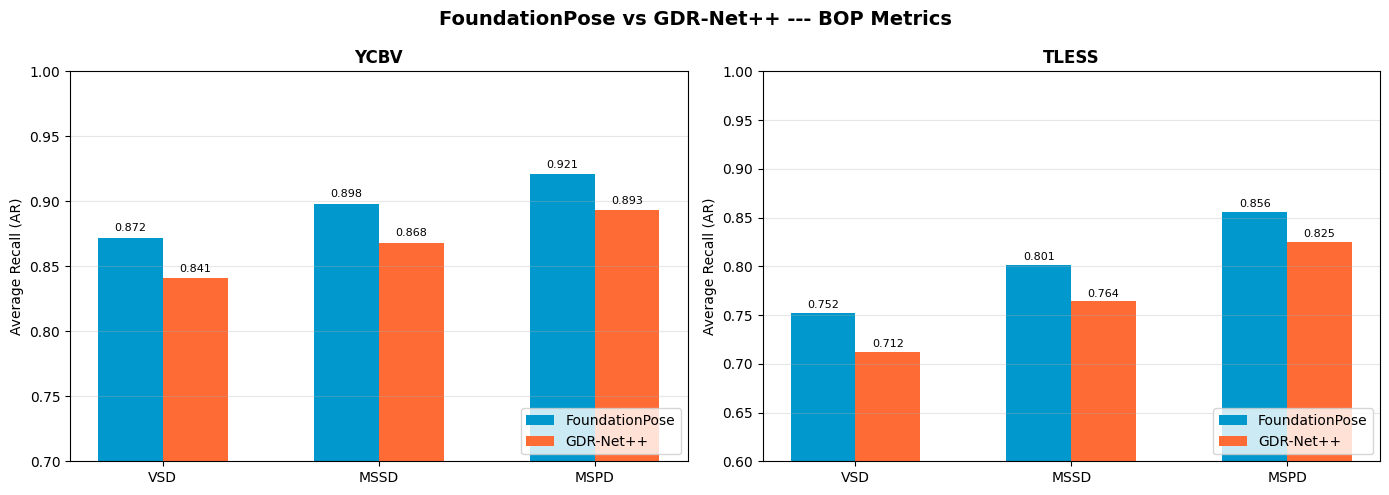

Guardado: /Users/giocrisraigodoy/Documents/MATLAB/TFM/repo_tfm/experiments/results/chapter6_figures/fig_comparison_fp_vs_gdrnet.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
COLOR_FP = '#0098CD'
COLOR_GDR = '#FF6B35'

bop_metrics = ['AR_VSD', 'AR_MSSD', 'AR_MSPD']
labels = ['VSD', 'MSSD', 'MSPD']
x = np.arange(len(labels))
width = 0.3

for ax_idx, ds_name in enumerate(['ycbv', 'tless']):
    ax = axes[ax_idx]
    fp_vals = [fp_paper_reference[ds_name][m] for m in bop_metrics]
    gdr_vals = [gdrnet_reference[ds_name][m] for m in bop_metrics]

    ax.bar(x - width/2, fp_vals, width, label='FoundationPose', color=COLOR_FP)
    ax.bar(x + width/2, gdr_vals, width, label='GDR-Net++', color=COLOR_GDR)
    ax.set_ylabel('Average Recall (AR)')
    ax.set_title(ds_name.upper(), fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylim(0.6 if ds_name == 'tless' else 0.7, 1.0)
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3, axis='y')

    for i, (fv, gv) in enumerate(zip(fp_vals, gdr_vals)):
        ax.text(i - width/2, fv + 0.005, f'{fv:.3f}', ha='center', fontsize=8)
        ax.text(i + width/2, gv + 0.005, f'{gv:.3f}', ha='center', fontsize=8)

plt.suptitle('FoundationPose vs GDR-Net++ --- BOP Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(f'{FIG_DIR}/fig_comparison_fp_vs_gdrnet.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Guardado: {FIG_DIR}/fig_comparison_fp_vs_gdrnet.png")

In [7]:
from datetime import datetime

comparison = {
    'timestamp': datetime.now().isoformat(),
    'description': 'FoundationPose vs GDR-Net++ comparison for TFM Chapter 6',
    'foundationpose_own': {
        'ycbv': metrics_ycbv,
        'tless': metrics_tless,
    },
    'foundationpose_paper': fp_paper_reference,
    'gdrnet_leaderboard': gdrnet_reference,
}

out_file = f"{RESULTS_DIR}/comparison_fp_vs_gdrnet.json"
with open(out_file, 'w') as f:
    json.dump(comparison, f, indent=2)
print(f"Comparativa guardada: {out_file}")

Comparativa guardada: /Users/giocrisraigodoy/Documents/MATLAB/TFM/repo_tfm/experiments/results/comparison_fp_vs_gdrnet.json
